In [2]:
# Install required packages
%pip install scikit-learn tensorflow matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Load the preprocessed dataset
df = pd.read_csv('df_preprocessed.csv')
df['cleaned_text'] = df['cleaned_text'].fillna('')  # Handle any missing values safely

# 2. Extract features and labels
X = df['cleaned_text'].values
y = df['label_encoded'].values

print("Dataset loaded successfully!")
print(f"Total number of samples: {X.shape[0]}")

Dataset loaded successfully!
Total number of samples: 21431


In [4]:
# Split dataset (80% Train, 20% Test)
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples (Train): {X_train_text.shape[0]}")
print(f"Testing samples (Test): {X_test_text.shape[0]}")

Training samples (Train): 17144
Testing samples (Test): 4287


In [5]:
# 1. Define hyper-parameters
max_words = 10000  # Vocabulary size
max_len = 100      # Fixed sequence length

# 2. Initialize and fit Tokenizer on training data ONLY
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_text)

print("Tokenizer has been built and fitted successfully!")

Tokenizer has been built and fitted successfully!


In [6]:
# 3. Convert text strings to sequences of numerical IDs
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

print("Sample of text converted to numeric sequences:")
print(f"Original text: {X_train_text[0]}")
print(f"Numeric sequence: {X_train_seq[0]}")

Sample of text converted to numeric sequences:
Original text: yesterday feel really stress anxious before suppose wash up some dish really help stay present worry much then watch video see wash dish help stress anxiety guess work
Numeric sequence: [729, 3, 24, 39, 126, 92, 643, 877, 20, 50, 857, 24, 17, 181, 659, 215, 28, 46, 100, 51, 58, 877, 857, 17, 39, 18, 424, 21]


In [7]:
# 4. Apply Padding/Truncating to ensure uniform input matrix size
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print("Padding completed successfully!")
print(f"Final training matrix shape for CNN: {X_train_pad.shape}")

Padding completed successfully!
Final training matrix shape for CNN: (17144, 100)


In [8]:
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),

    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.3),  # 
    Dense(3, activation='softmax')
])

# Compile the model with loss and optimizer
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

# Print the architecture summary for your report/presentation
model.summary()

c:\Users\dalia\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
print("Starting 1D CNN Model Training...")

# Train the model and save the training history
history = model.fit(X_train_pad, y_train, 
                    epochs=5, 
                    batch_size=32, 
                    validation_data=(X_test_pad, y_test))

model.save("cnn_model.h5")
print("CNN model saved successfully!")

Starting 1D CNN Model Training...
Epoch 1/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.7244 - loss: 0.6564 - val_accuracy: 0.7761 - val_loss: 0.5370
Epoch 2/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8513 - loss: 0.3972 - val_accuracy: 0.7814 - val_loss: 0.5572
Epoch 3/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9299 - loss: 0.2053 - val_accuracy: 0.7756 - val_loss: 0.6467
Epoch 4/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9747 - loss: 0.0883 - val_accuracy: 0.7714 - val_loss: 0.7880
Epoch 5/5
536/536 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9893 - loss: 0.0416 - val_accuracy: 0.7637 - val_loss: 0.9430


CNN model saved successfully!


In [10]:
# Evaluate performance on the unseen test set
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("-" * 40)
print(f"Final 1D CNN Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final 1D CNN Test Loss: {loss:.4f}")
print("-" * 40)

134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7637 - loss: 0.9430
----------------------------------------
Final 1D CNN Test Accuracy: 76.37%
Final 1D CNN Test Loss: 0.9430
----------------------------------------


134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


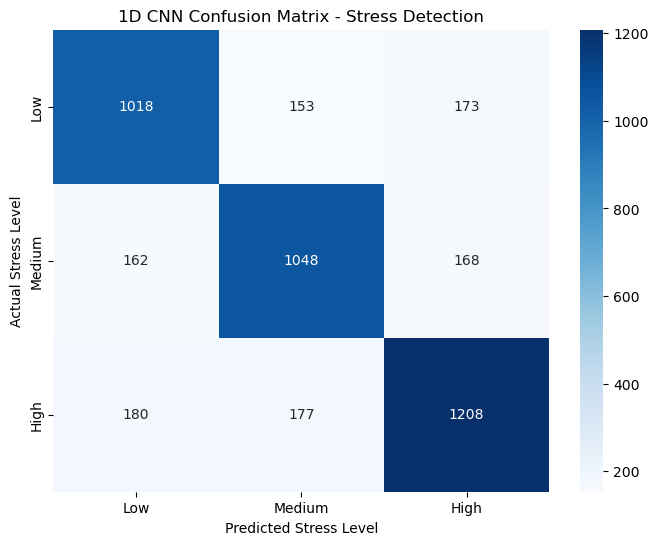

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get the model's predicted probabilities for the test set
y_pred_probs = model.predict(X_test_pad)

# 2. Convert probabilities to class labels (0, 1, or 2) by picking the highest probability
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Define your class names (Make sure the order matches your label encoding, e.g., Low, Medium, High)
class_names = ['Low', 'Medium', 'High']

# 5. Plot the Confusion Matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('1D CNN Confusion Matrix - Stress Detection')
plt.ylabel('Actual Stress Level')
plt.xlabel('Predicted Stress Level')
plt.show()